# Aravind's Contribution

In [16]:
# General Python
import os
import random
import numpy as np
import pandas as pd

# Image Handling
import cv2
from PIL import Image

# Deep Learning 
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Sklearn Utilities
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings 
import warnings
warnings.filterwarnings('ignore')

## Importing Data

In [23]:
TRAIN_DIR = "./train"   
TEST_DIR  = "./test"   
IMG_SIZE = (128, 128)
BATCH_SIZE = 8
SAMPLE_SIZE = 1000
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [24]:
def make_sampled_df(root_dir, sample_size_per_class=1000):
    data = []
    for class_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir): continue
        images = [os.path.join(class_dir, img) for img in os.listdir(class_dir)
                  if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sampled = random.sample(images, min(sample_size_per_class, len(images)))
        for img_path in sampled:
            data.append({'filename': img_path, 'class': class_name})
    return pd.DataFrame(data)

train_df = make_sampled_df(TRAIN_DIR, SAMPLE_SIZE)
test_df  = make_sampled_df(TEST_DIR, SAMPLE_SIZE)  

print("Sampled train counts:\n", train_df['class'].value_counts())
print("Sampled test counts:\n", test_df['class'].value_counts())

Sampled train counts:
 class
drink      1000
food       1000
inside     1000
menu       1000
outside    1000
Name: count, dtype: int64
Sampled test counts:
 class
drink      1000
food       1000
inside     1000
menu       1000
outside    1000
Name: count, dtype: int64


## Create Data Generators

In [25]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)
test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print("Classes:", train_gen.class_indices)

Found 5000 validated image filenames belonging to 5 classes.
Found 5000 validated image filenames belonging to 5 classes.
Classes: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


## # Build the model (initial: all VGG layers frozen)

In [28]:
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
for layer in vgg_base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(vgg_base.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=vgg_base.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          65,6

 Total params: 14,780,997 (56.39 MB)

 Trainable params: 66,309 (259.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

##  Initial Training (All Layers Frozen, 3 Epochs)

In [29]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)
chkpt = ModelCheckpoint("vgg16_tl_best.h5", save_best_only=True)

history_1 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=3,
    callbacks=[early_stop, chkpt]
)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.3418 - loss: 1.5491

625/625 ━━━━━━━━━━━━━━━━━━━━ 950s 2s/step - accuracy: 0.3420 - loss: 1.5488 - val_accuracy: 0.6724 - val_loss: 1.0272
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.6203 - loss: 1.0262

625/625 ━━━━━━━━━━━━━━━━━━━━ 918s 1s/step - accuracy: 0.6203 - loss: 1.0261 - val_accuracy: 0.7168 - val_loss: 0.8431
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.6802 - loss: 0.8674

625/625 ━━━━━━━━━━━━━━━━━━━━ 935s 1s/step - accuracy: 0.6802 - loss: 0.8674 - val_accuracy: 0.7334 - val_loss: 0.7681


## Initial Training Model Evaluation

625/625 ━━━━━━━━━━━━━━━━━━━━ 474s 757ms/step

Test Accuracy: 73.34%

Classification Report:
               precision    recall  f1-score   support

       drink       0.74      0.58      0.65      1000
        food       0.78      0.87      0.83      1000
      inside       0.65      0.61      0.63      1000
        menu       0.82      0.88      0.85      1000
     outside       0.66      0.72      0.69      1000

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000



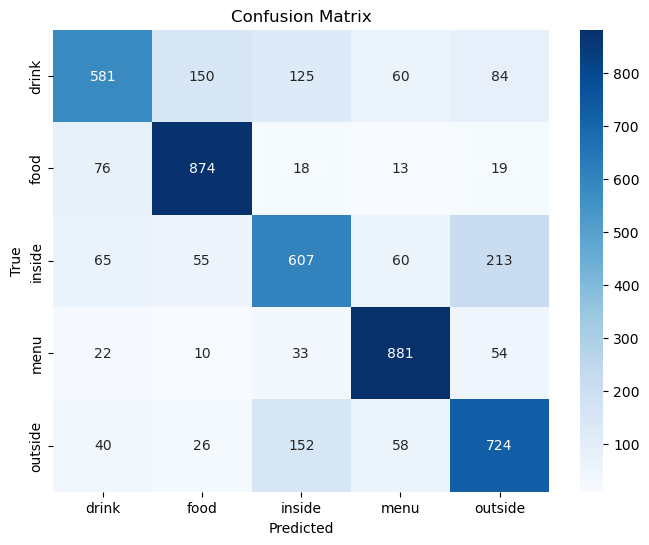

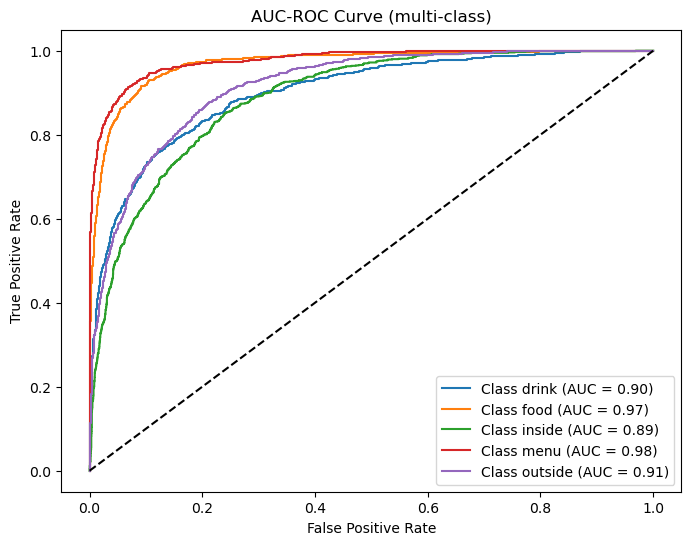


Micro-averaged AUC: 0.9351


In [30]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

class_names = ['drink', 'food', 'inside', 'menu', 'outside']
NUM_CLASSES = len(class_names)

# --- Predictions ---
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

# --- Accuracy & Report ---
acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {acc*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# --- AUC & ROC Curves ---
# Binarize labels for multi-class ROC/AUC
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_name} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("AUC-ROC Curve (multi-class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"\nMicro-averaged AUC: {roc_auc['micro']:.4f}")

## Fine-Tuning: Unfreeze Last 4 Layers, Train 3 More Epochs

In [31]:
# Unfreeze the last 4 VGG layers
for layer in vgg_base.layers[-4:]:
    layer.trainable = True

# Lower learning rate for fine-tuning!
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

chkpt_ft = ModelCheckpoint("vgg16_finetune_best.h5", save_best_only=True)
history_2 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=3,
    callbacks=[early_stop, chkpt_ft]
)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 998ms/step - accuracy: 0.7378 - loss: 0.6983

625/625 ━━━━━━━━━━━━━━━━━━━━ 1111s 2s/step - accuracy: 0.7379 - loss: 0.6982 - val_accuracy: 0.8136 - val_loss: 0.5010
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.8318 - loss: 0.4540

625/625 ━━━━━━━━━━━━━━━━━━━━ 840s 1s/step - accuracy: 0.8318 - loss: 0.4540 - val_accuracy: 0.8146 - val_loss: 0.4856
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.8633 - loss: 0.3660

625/625 ━━━━━━━━━━━━━━━━━━━━ 880s 1s/step - accuracy: 0.8633 - loss: 0.3660 - val_accuracy: 0.8428 - val_loss: 0.4195


## Fine Tuning Model Evaluation

625/625 ━━━━━━━━━━━━━━━━━━━━ 443s 707ms/step

Test Accuracy after fine-tuning: 84.28%

Classification Report:
               precision    recall  f1-score   support

       drink       0.80      0.80      0.80      1000
        food       0.85      0.94      0.89      1000
      inside       0.79      0.74      0.76      1000
        menu       0.95      0.92      0.93      1000
     outside       0.84      0.82      0.83      1000

    accuracy                           0.84      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.84      0.84      0.84      5000



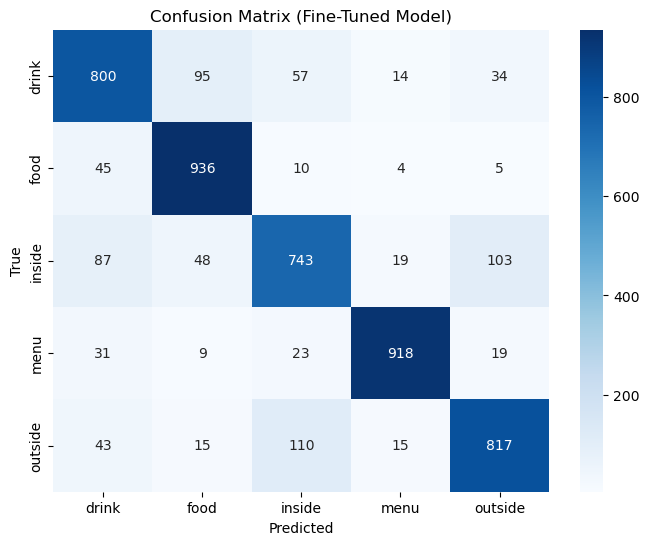

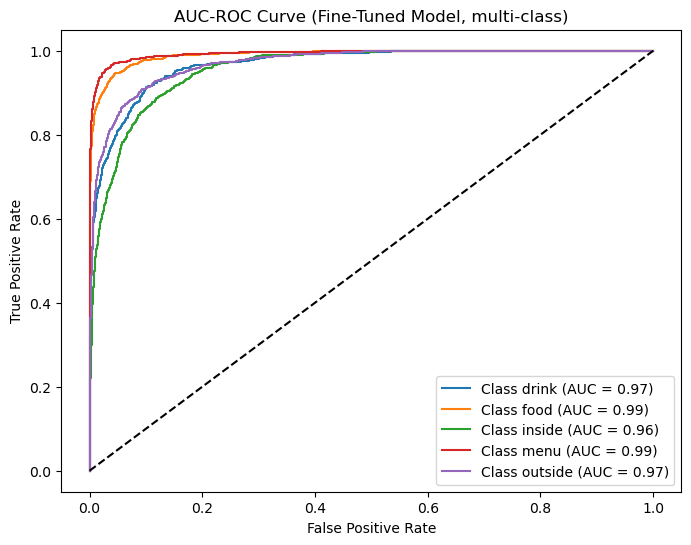


Micro-averaged AUC after fine-tuning: 0.9775


In [32]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

class_names = ['drink', 'food', 'inside', 'menu', 'outside']
NUM_CLASSES = len(class_names)

# ---- Get Predictions ----
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)  
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

# ---- Accuracy & Report ----
acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy after fine-tuning: {acc*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Fine-Tuned Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---- AUC & ROC Curves ----
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_name} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("AUC-ROC Curve (Fine-Tuned Model, multi-class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"\nMicro-averaged AUC after fine-tuning: {roc_auc['micro']:.4f}")

## Plot Accuracy and Loss Curves for both models

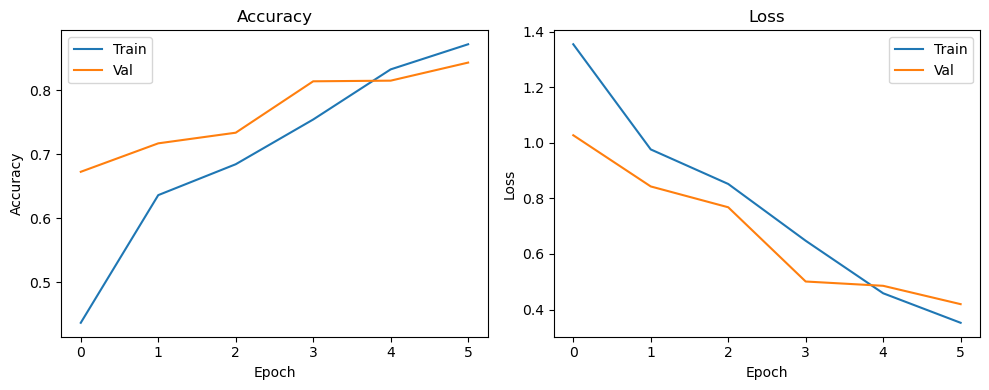

In [33]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_1.history['accuracy'] + history_2.history['accuracy'], label='Train')
plt.plot(history_1.history['val_accuracy'] + history_2.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_1.history['loss'] + history_2.history['loss'], label='Train')
plt.plot(history_1.history['val_loss'] + history_2.history['val_loss'], label='Val')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Load Both Models

In [34]:
from tensorflow.keras.models import load_model

model_frozen = load_model("vgg16_tl_best.h5")
model_finetuned = load_model("vgg16_finetune_best.h5")

## Prediction Function

In [35]:
def get_preds_and_labels(model, test_gen, num_classes):
    test_gen.reset()
    y_pred_prob = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_gen.classes
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    return y_true, y_pred, y_pred_prob, y_true_bin

## Evaluate Both Models

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

class_names = ['drink', 'food', 'inside', 'menu', 'outside']
NUM_CLASSES = len(class_names)

# Get predictions and true labels
y_true_frozen, y_pred_frozen, y_prob_frozen, y_true_bin_frozen = get_preds_and_labels(model_frozen, test_gen, NUM_CLASSES)
y_true_finetuned, y_pred_finetuned, y_prob_finetuned, y_true_bin_finetuned = get_preds_and_labels(model_finetuned, test_gen, NUM_CLASSES)

625/625 ━━━━━━━━━━━━━━━━━━━━ 503s 805ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 505s 807ms/step


## Compare Accuracy and Classification Reports

In [37]:
print("Transfer Learning (Frozen)")
acc_frozen = accuracy_score(y_true_frozen, y_pred_frozen)
print(f"Test Accuracy: {acc_frozen*100:.2f}%")
print("Classification Report:\n", classification_report(y_true_frozen, y_pred_frozen, target_names=class_names))

print("\nFine-Tuned (Last 4 Unfrozen)")
acc_finetuned = accuracy_score(y_true_finetuned, y_pred_finetuned)
print(f"Test Accuracy: {acc_finetuned*100:.2f}%")
print("Classification Report:\n", classification_report(y_true_finetuned, y_pred_finetuned, target_names=class_names))

Transfer Learning (Frozen)
Test Accuracy: 73.34%
Classification Report:
               precision    recall  f1-score   support

       drink       0.74      0.58      0.65      1000
        food       0.78      0.87      0.83      1000
      inside       0.65      0.61      0.63      1000
        menu       0.82      0.88      0.85      1000
     outside       0.66      0.72      0.69      1000

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000


Fine-Tuned (Last 4 Unfrozen)
Test Accuracy: 84.28%
Classification Report:
               precision    recall  f1-score   support

       drink       0.80      0.80      0.80      1000
        food       0.85      0.94      0.89      1000
      inside       0.79      0.74      0.76      1000
        menu       0.95      0.92      0.93      1000
     outside       0.84      0.82      0.83      1000

    accuracy                        

## Side-by-Side Confusion Matrices

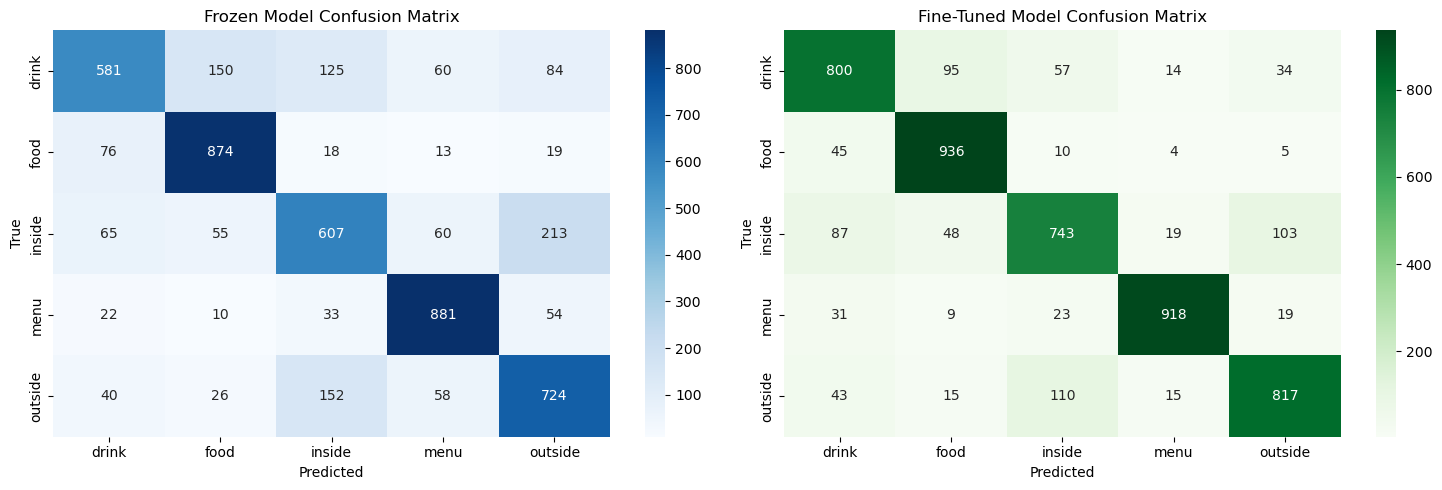

In [38]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
cm1 = confusion_matrix(y_true_frozen, y_pred_frozen)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Frozen Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1,2,2)
cm2 = confusion_matrix(y_true_finetuned, y_pred_finetuned)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title("Fine-Tuned Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Side-by-Side ROC Curves and Micro-Averaged AUC

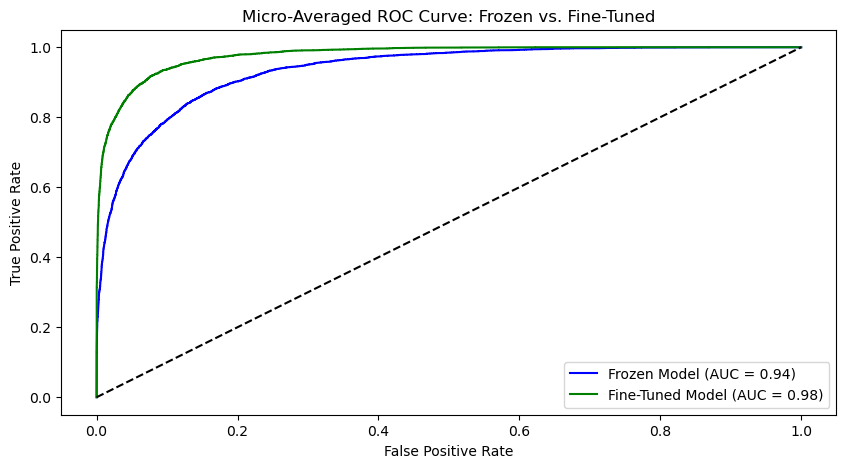

Micro-Averaged AUC (Frozen):    0.9351
Micro-Averaged AUC (Fine-Tuned):0.9775


In [39]:
# Compute ROC/AUC for micro-averaged
fpr_frozen, tpr_frozen, _ = roc_curve(y_true_bin_frozen.ravel(), y_prob_frozen.ravel())
roc_auc_frozen = auc(fpr_frozen, tpr_frozen)

fpr_finetuned, tpr_finetuned, _ = roc_curve(y_true_bin_finetuned.ravel(), y_prob_finetuned.ravel())
roc_auc_finetuned = auc(fpr_finetuned, tpr_finetuned)

plt.figure(figsize=(10,5))
plt.plot(fpr_frozen, tpr_frozen, label=f'Frozen Model (AUC = {roc_auc_frozen:.2f})', color='blue')
plt.plot(fpr_finetuned, tpr_finetuned, label=f'Fine-Tuned Model (AUC = {roc_auc_finetuned:.2f})', color='green')
plt.plot([0,1], [0,1], 'k--')
plt.title("Micro-Averaged ROC Curve: Frozen vs. Fine-Tuned")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"Micro-Averaged AUC (Frozen):    {roc_auc_frozen:.4f}")
print(f"Micro-Averaged AUC (Fine-Tuned):{roc_auc_finetuned:.4f}")

## Third Round of Tuning with Unfreeze more - unfreeze last 8 VGG layers

In [40]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [41]:
for layer in vgg_base.layers[-8:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-6), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop3 = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)
chkpt3 = ModelCheckpoint("vgg16_tune3_best.h5", save_best_only=True)

history_3 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=3,
    callbacks=[early_stop3, chkpt3]
)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9170 - loss: 0.2475

625/625 ━━━━━━━━━━━━━━━━━━━━ 1396s 2s/step - accuracy: 0.9170 - loss: 0.2475 - val_accuracy: 0.8584 - val_loss: 0.3944
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9293 - loss: 0.2223

625/625 ━━━━━━━━━━━━━━━━━━━━ 1311s 2s/step - accuracy: 0.9293 - loss: 0.2223 - val_accuracy: 0.8586 - val_loss: 0.3889
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9395 - loss: 0.1915

625/625 ━━━━━━━━━━━━━━━━━━━━ 1123s 2s/step - accuracy: 0.9395 - loss: 0.1915 - val_accuracy: 0.8614 - val_loss: 0.3844


## Third Round Model Evaluation

625/625 ━━━━━━━━━━━━━━━━━━━━ 419s 669ms/step

Test Accuracy after Third Round of Tuning: 86.14%

Classification Report:
               precision    recall  f1-score   support

       drink       0.82      0.85      0.84      1000
        food       0.94      0.89      0.91      1000
      inside       0.78      0.80      0.79      1000
        menu       0.93      0.94      0.93      1000
     outside       0.85      0.83      0.84      1000

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



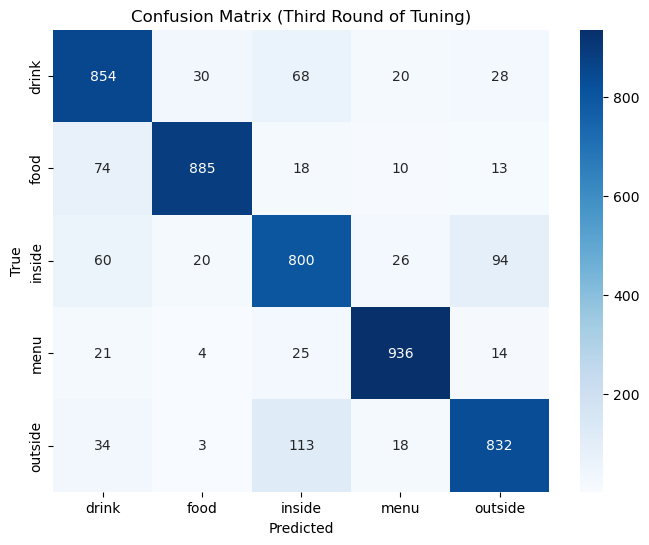

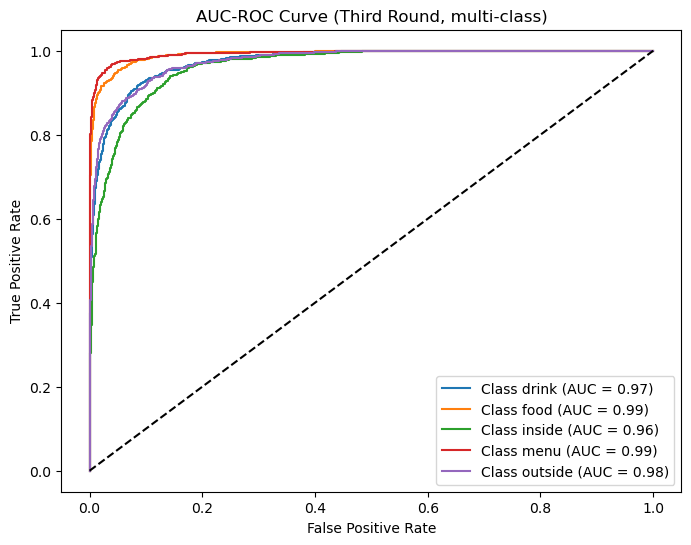


Micro-averaged AUC after Third Round of Tuning: 0.9814


In [42]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

class_names = ['drink', 'food', 'inside', 'menu', 'outside']
NUM_CLASSES = len(class_names)

# --- Get predictions ---
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)  
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

# --- Accuracy & Classification Report ---
acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy after Third Round of Tuning: {acc*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Third Round of Tuning)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# --- AUC & ROC Curves ---
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_name} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("AUC-ROC Curve (Third Round, multi-class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"\nMicro-averaged AUC after Third Round of Tuning: {roc_auc['micro']:.4f}")

## LLM Prompts
- how to create data generators
- how to import vgg16 model
- different ways of model tuning of vgg16